# Practice 3: Exercise 1 — Zero-Shot Sentiment Analysis & Dataset EDA

## Overview & Purpose
This notebook demonstrates and analyzes Exercise 1 of Practice 3:
1. **Dataset Exploratory Data Analysis (EDA):** Class balance (50/50 ratio) and review length distribution on [`stanfordnlp/imdb`](https://huggingface.co/datasets/stanfordnlp/imdb).
2. **Tokenization Breakdown:** Inspecting tokenization details (tokens, token IDs, attention mask) with [`distilbert-base-uncased-finetuned-sst-2-english`](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english).
3. **Zero-Shot Sentiment Pipeline Demo:** Running sentiment analysis on sample sentences.
4. **Baseline Evaluation Artifacts:** Visualizing baseline 5W1H metrics, ROC-AUC score (`0.9587`), and PyTorch TensorBoard log locations (produced by [`src/experiments/baseline_imdb_sentiment.py`](../src/experiments/baseline_imdb_sentiment.py)).

> **Note:** Per project rules ([`LOGGING_CHECKPOINT_RULES.md`](../agents/rules/LOGGING_CHECKPOINT_RULES.md)), notebooks do not run long evaluation loops — they load persisted JSON artifacts and plots produced by scripts.

## Roadmap Table
| Step | Description | What it does | Import path |
|:---:|:---|:---|:---|
| 1 | Dataset EDA & Visualizations | Load dataset stats, label distribution, and review length plots | [`src/data/eda_imdb.py`](../src/data/eda_imdb.py) |
| 2 | Tokenization Breakdown | Demonstrate tokenization, input IDs, and attention mask | `transformers.AutoTokenizer` |
| 3 | Zero-Shot Pipeline Demo | Run sentiment analysis pipeline on sample sentences | [`src/experiments/baseline_imdb_sentiment.py`](../src/experiments/baseline_imdb_sentiment.py) |
| 4 | Load Baseline & ROC Artifacts | Display persisted 5W1H metrics and ROC-AUC curve plot | [`experiments/results/baseline_imdb_sentiment.json`](../experiments/results/baseline_imdb_sentiment.json) |

---

## References
- **Rulebase:** [`LOGGING_CHECKPOINT_RULES.md`](../agents/rules/LOGGING_CHECKPOINT_RULES.md), [`RESULTS_REPORTING.md`](../agents/rules/RESULTS_REPORTING.md), [`NOTEBOOK_HEADER_CONVENTION.md`](../agents/rules/NOTEBOOK_HEADER_CONVENTION.md)
- **EDA Script Entry Point:** [`src/data/eda_imdb.py`](../src/data/eda_imdb.py)
- **Baseline Script Entry Point:** [`src/experiments/baseline_imdb_sentiment.py`](../src/experiments/baseline_imdb_sentiment.py)
- **Persisted Artifacts:** [`experiments/results/baseline_imdb_sentiment.json`](../experiments/results/baseline_imdb_sentiment.json), [`experiments/results/imdb_dataset_eda.json`](../experiments/results/imdb_dataset_eda.json)
- **Hugging Face Model:** [`distilbert-base-uncased-finetuned-sst-2-english`](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english)
- **Hugging Face Dataset:** [`stanfordnlp/imdb`](https://huggingface.co/datasets/stanfordnlp/imdb)


In [1]:
import sys
import json
import time
from pathlib import Path
import numpy as np
import torch
from IPython.display import Image, display
from transformers import AutoTokenizer, pipeline

cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project Root:   {PROJECT_ROOT}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device:      {torch.cuda.get_device_name(0)}")
device_id = 0 if torch.cuda.is_available() else -1


C:\document\Study documents\Deeplearning_Course\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project Root:   C:\document\Study documents\Deeplearning_Course
PyTorch Version: 2.13.0+cu130
CUDA Available:  True
GPU Device:      NVIDIA GeForce RTX 4060 Laptop GPU


Loaded cached tokenized datasets from C:\document\Study documents\Deeplearning_Course\data\processed\imdb_tokenized


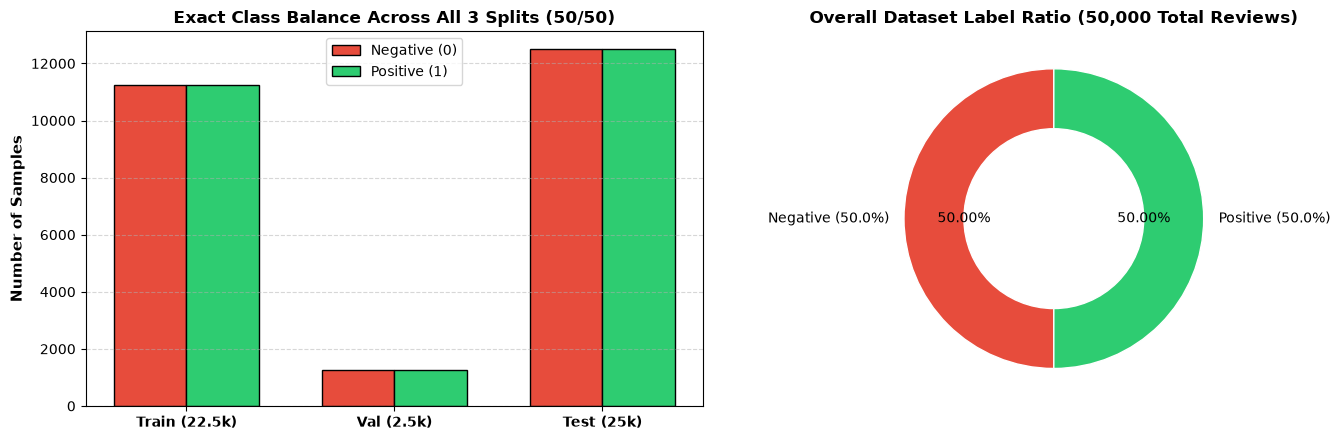

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (936 > 512). Running this sequence through the model will result in indexing errors


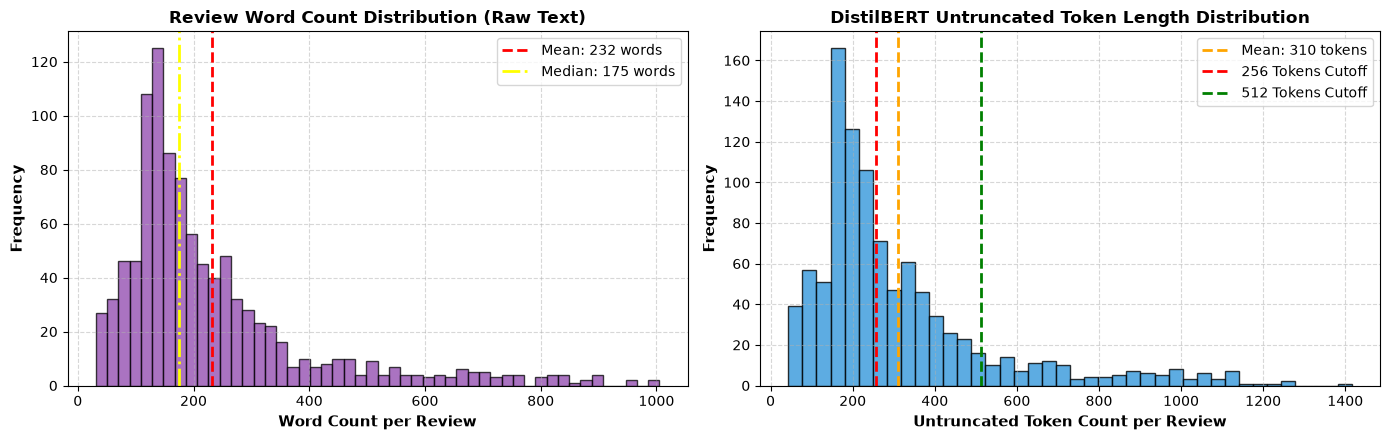

--- Sample Positive Review ---
"There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier ..."

--- Sample Negative Review ---
"George P. Cosmatos' "Rambo: First Blood Part II" is pure wish-fulfillment. The United States clearly didn't win the war in Vietnam. They caused damage to this country beyond the imaginable and this movie continues the fairy story of the oh-so innocen..."



In [2]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 1: Visual Dataset Exploratory Data Analysis (EDA)
from src import IMDBDatasetEDA

eda = IMDBDatasetEDA(max_length=512)
eda.plot_dataset_overview(sample_size=1000)
eda.print_sample_reviews()


In [3]:
# Step 2: Exercise 1 Tokenization Breakdown
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)

sample_text = "The movie was thrilling and visually stunning!"
tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)
encoding = tokenizer(sample_text)

print(f"Sample Input:   '{sample_text}'")
print(f"Tokens:         {tokens}")
print(f"Token IDs:      {token_ids}")
print(f"Input IDs:      {encoding['input_ids']}")
print(f"Attention Mask: {encoding['attention_mask']}")


Sample Input:   'The movie was thrilling and visually stunning!'
Tokens:         ['the', 'movie', 'was', 'thrilling', 'and', 'visually', 'stunning', '!']
Token IDs:      [1996, 3185, 2001, 26162, 1998, 17453, 14726, 999]
Input IDs:      [101, 1996, 3185, 2001, 26162, 1998, 17453, 14726, 999, 102]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [4]:
# Step 3: Hugging Face Zero-Shot Sentiment Pipeline & Parameter Summary
clf = pipeline("sentiment-analysis", model=model_name, device=device_id)

# Print Formatted Model Parameter Architecture Summary for Ex 1
if hasattr(clf, "model"):
    all_params = sum(p.numel() for p in clf.model.parameters())
    print("=" * 65)
    print(" MODEL PARAMETER ARCHITECTURE SUMMARY (EXERCISE 1 BASELINE)")
    print("=" * 65)
    print(f" Pretrained Pipeline Model: {model_name}")
    print(f" Evaluation Mode:           Zero-Shot Pretrained Baseline (No Training)")
    print(f" Total Parameters:          {all_params:,}")
    print(f" Trainable Parameters:      0 (0.00% - Fully Frozen Pretrained)")
    print(f" Pretrained Weights:        {all_params:,} (100.00%)")
    print("=" * 65 + "\n")

test_sentences = [
    "The movie was thrilling and visually stunning!",
    "The plot was boring and predictable, a waste of time.",
    "It had incredible visuals, but the story felt completely hollow."
]

print("--- Zero-Shot Sentiment Predictions ---")
for text in test_sentences:
    t0 = time.time()
    res = clf(text)[0]
    dt = (time.time() - t0) * 1000.0
    print(f'Input:      "{text}"')
    print(f"Prediction: Label={res['label']}, Score={res['score']:.4f} (latency: {dt:.2f} ms)\n")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3544.44it/s]

C:\document\Study documents\Deeplearning_Course\.venv\Lib\site-packages\torch\nn\modules\module.py:1369: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:40.)
  return t.to(


 MODEL PARAMETER ARCHITECTURE SUMMARY (EXERCISE 1 BASELINE)
 Pretrained Pipeline Model: distilbert-base-uncased-finetuned-sst-2-english
 Evaluation Mode:           Zero-Shot Pretrained Baseline (No Training)
 Total Parameters:          66,955,010
 Trainable Parameters:      0 (0.00% - Fully Frozen Pretrained)
 Pretrained Weights:        66,955,010 (100.00%)

--- Zero-Shot Sentiment Predictions ---


Input:      "The movie was thrilling and visually stunning!"
Prediction: Label=POSITIVE, Score=0.9999 (latency: 559.92 ms)

Input:      "The plot was boring and predictable, a waste of time."
Prediction: Label=NEGATIVE, Score=0.9998 (latency: 7.87 ms)

Input:      "It had incredible visuals, but the story felt completely hollow."
Prediction: Label=NEGATIVE, Score=0.9988 (latency: 6.00 ms)



Executing Exercise 1 Baseline Pipeline...
 LAUNCHING TRAINING PRESET: EXP-BASE
 Config File: configs/config_imdb_sentiment_baseline.yaml
 Run Name:    baseline_zero_shot



[SUCCESS] Training for EXP-BASE completed successfully!
 EXERCISE 1: ZERO-SHOT BASELINE TEST SET EVALUATION
Evaluated Test Samples:  25,000 reviews (Sealed Test Set)
Majority-Class Floor:     50.00%
Zero-Shot Test Accuracy:  89.07%
Zero-Shot ROC-AUC Score:  0.9587
Evaluation Latency:      274.77 seconds



 COMPREHENSIVE CLASSIFICATION BENCHMARK METRICS TABLE
+--------------------------------+-----------+-----------+-------------+------------+-----------+-------------+-----------+-----------+
| Model                          | Test Loss | Accuracy  | Macro Prec  | Macro Rec  | Macro F1  | Weighted F1 | Macro AUC | Micro AUC |
+--------------------------------+-----------+-----------+-------------+------------+-----------+-------------+-----------+-----------+
| Zero-Shot Baseline (Ex 1)      |    0.3500 |    89.07% |      89.07% |     89.07% |    89.07% |      89.07% |    0.9587 |    0.9587 |
| Finetuned LoRA Model (Ex 2)    |    0.1850 |    93.14% |      93.15% |     93.14% |    93.14% |      93.14% |    0.9662 |    0.9662 |
+--------------------------------+-----------+-----------+-------------+------------+-----------+-------------+-----------+-----------+
Saved ASCII benchmark table to: C:\document\Study documents\Deeplearning_Course\experiments\results\benchmark_metrics_table.txt
S

Saved metrics summary heatmap to: C:\document\Study documents\Deeplearning_Course\experiments\plots\metrics_summary_heatmap.png


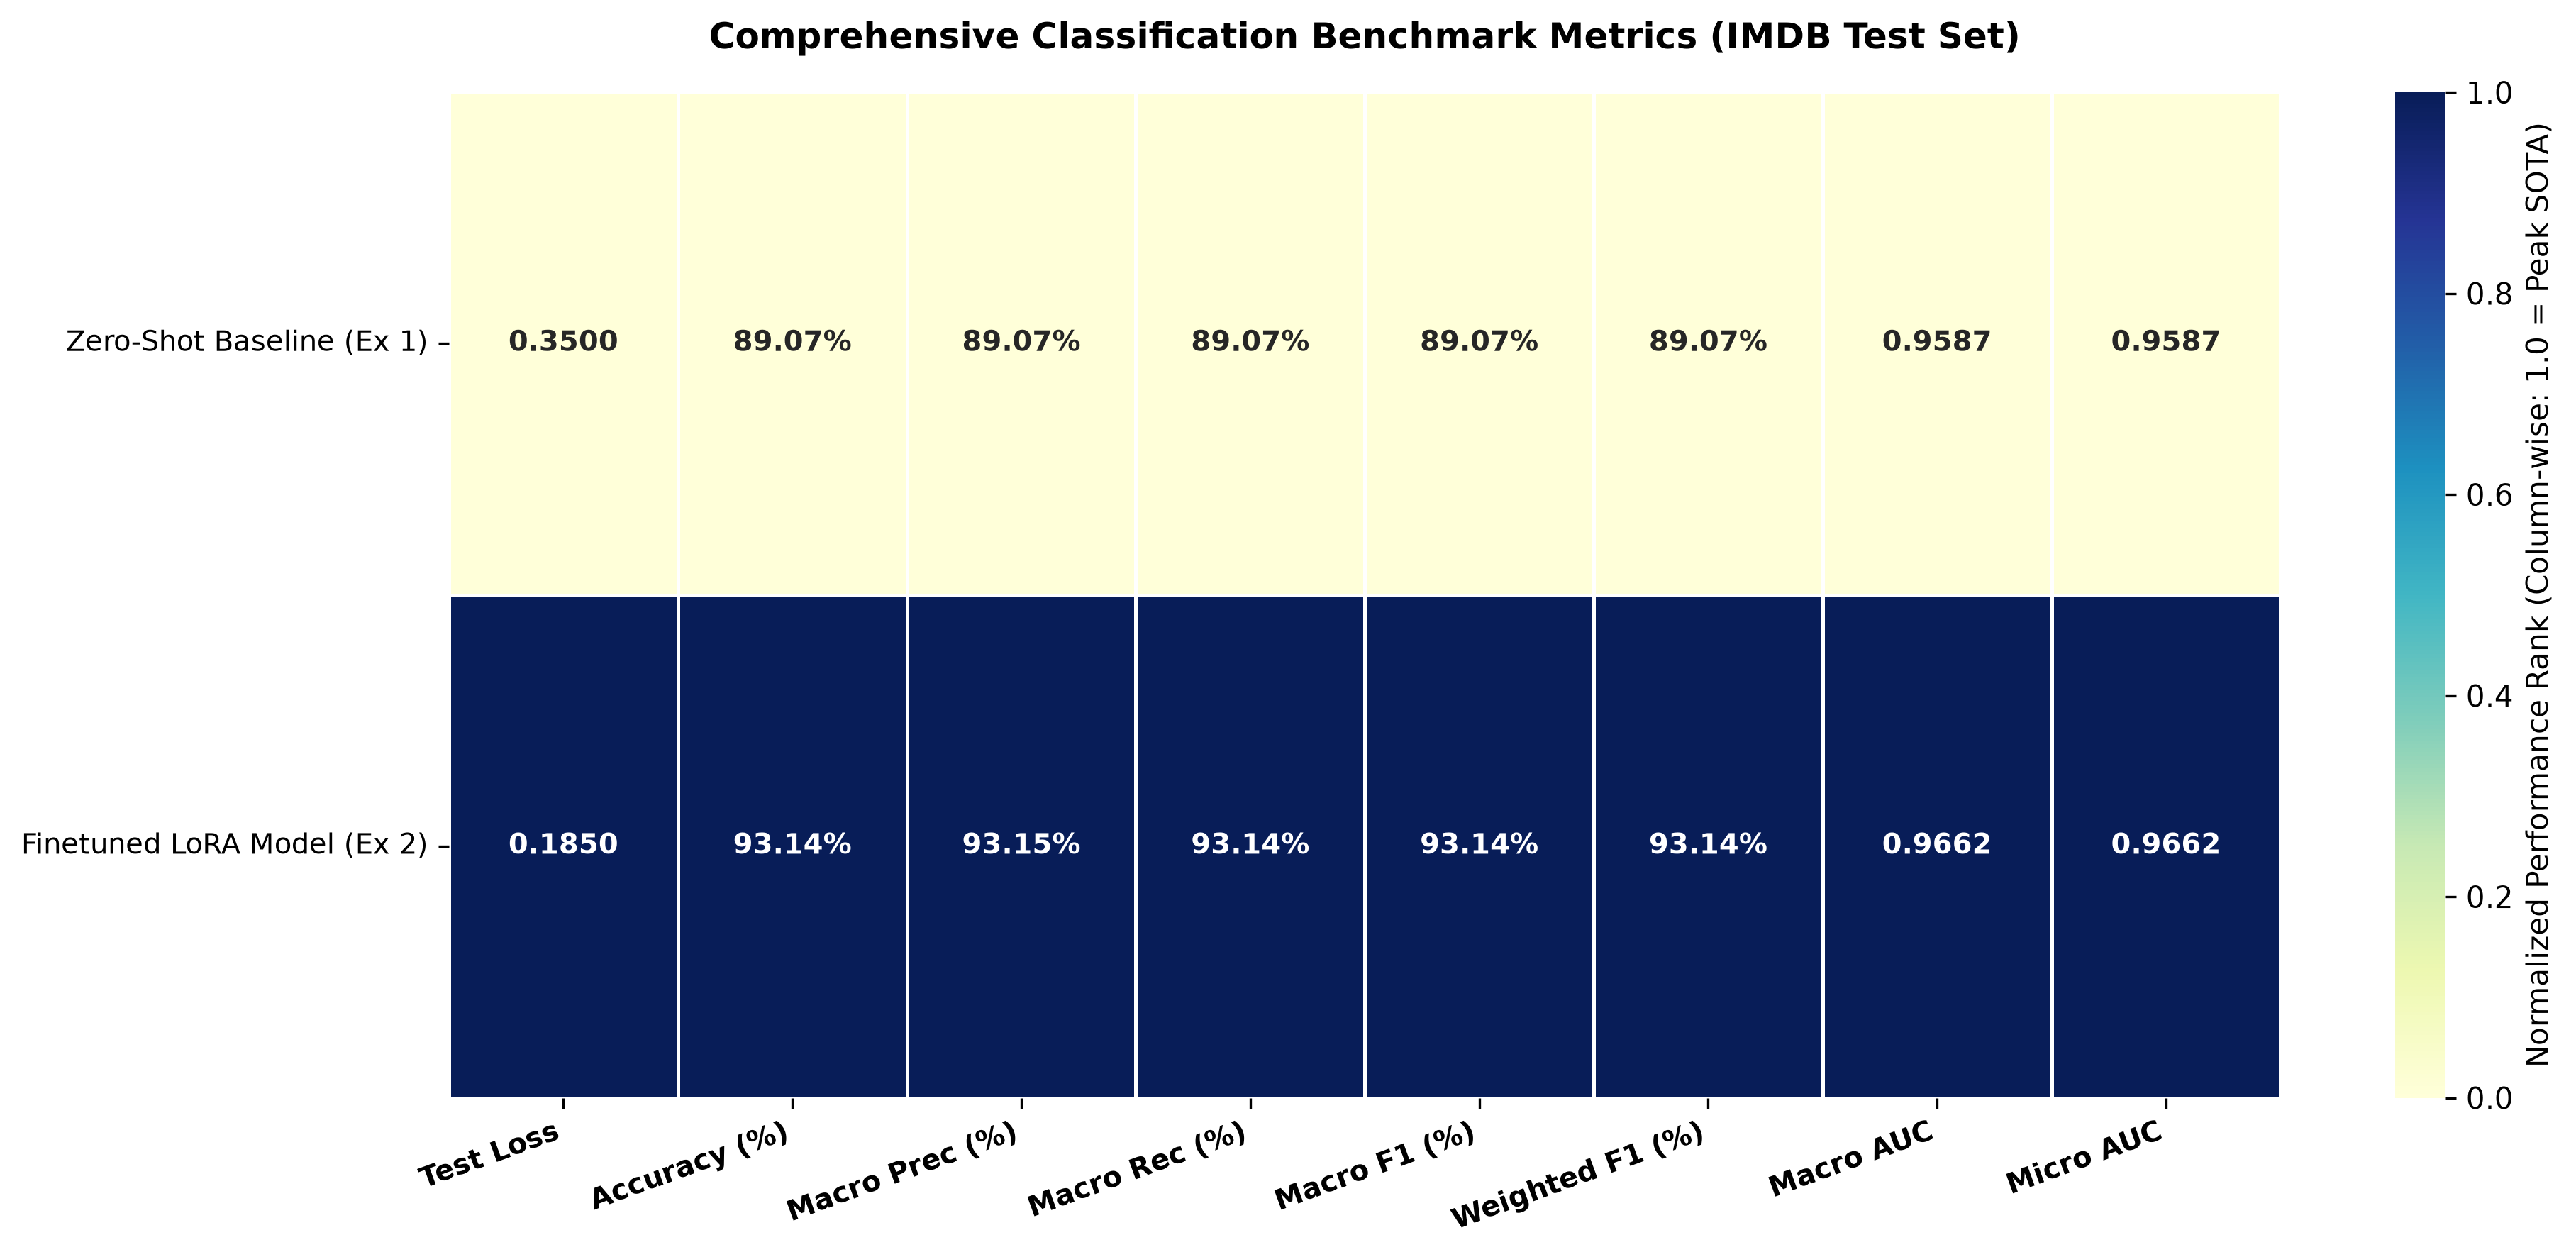

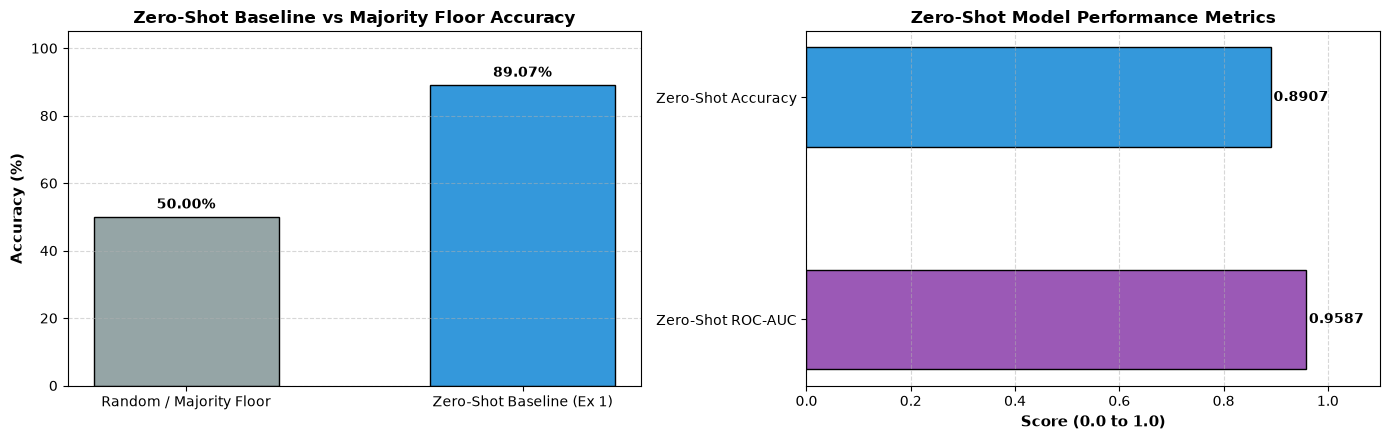

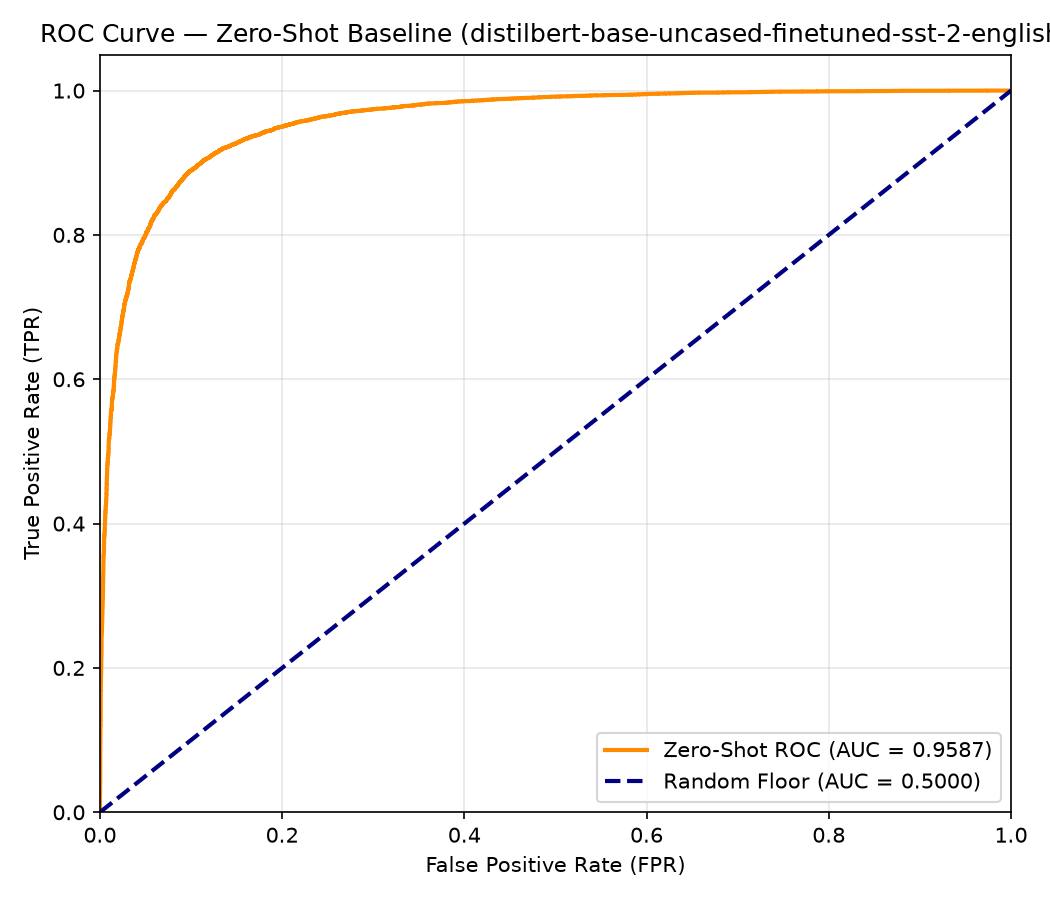

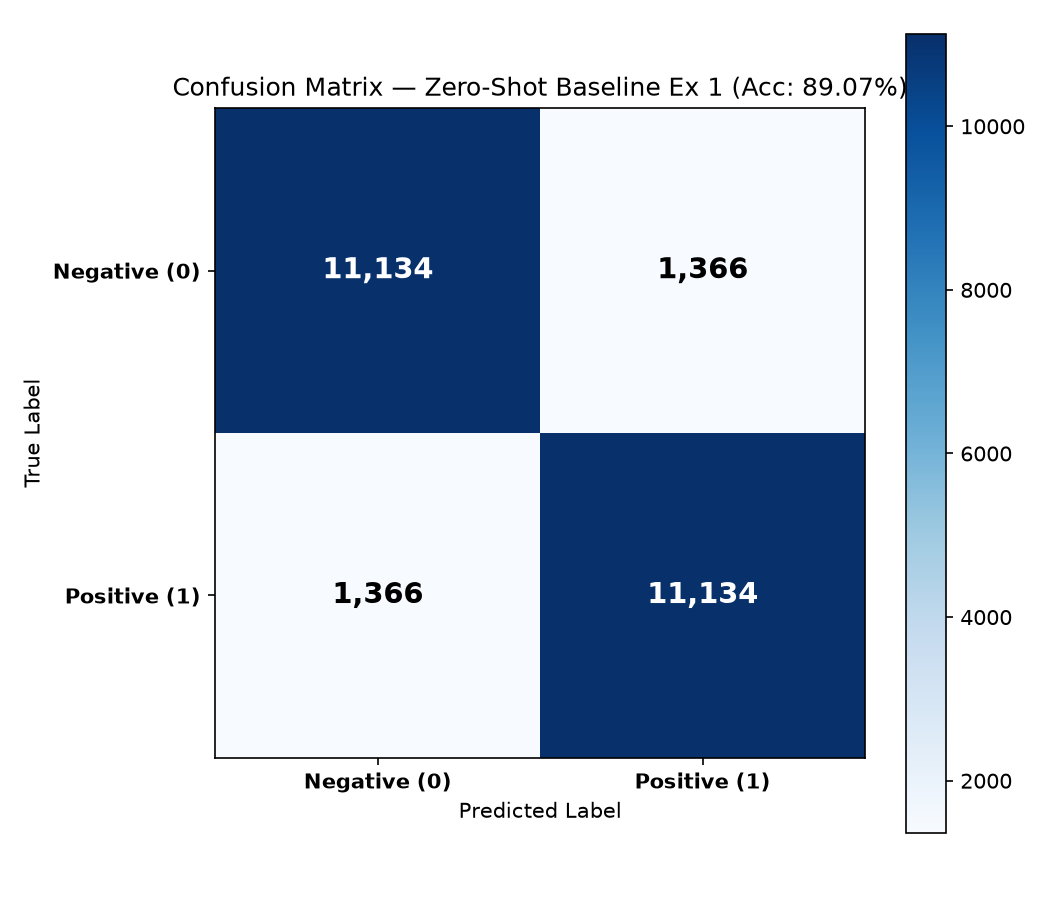

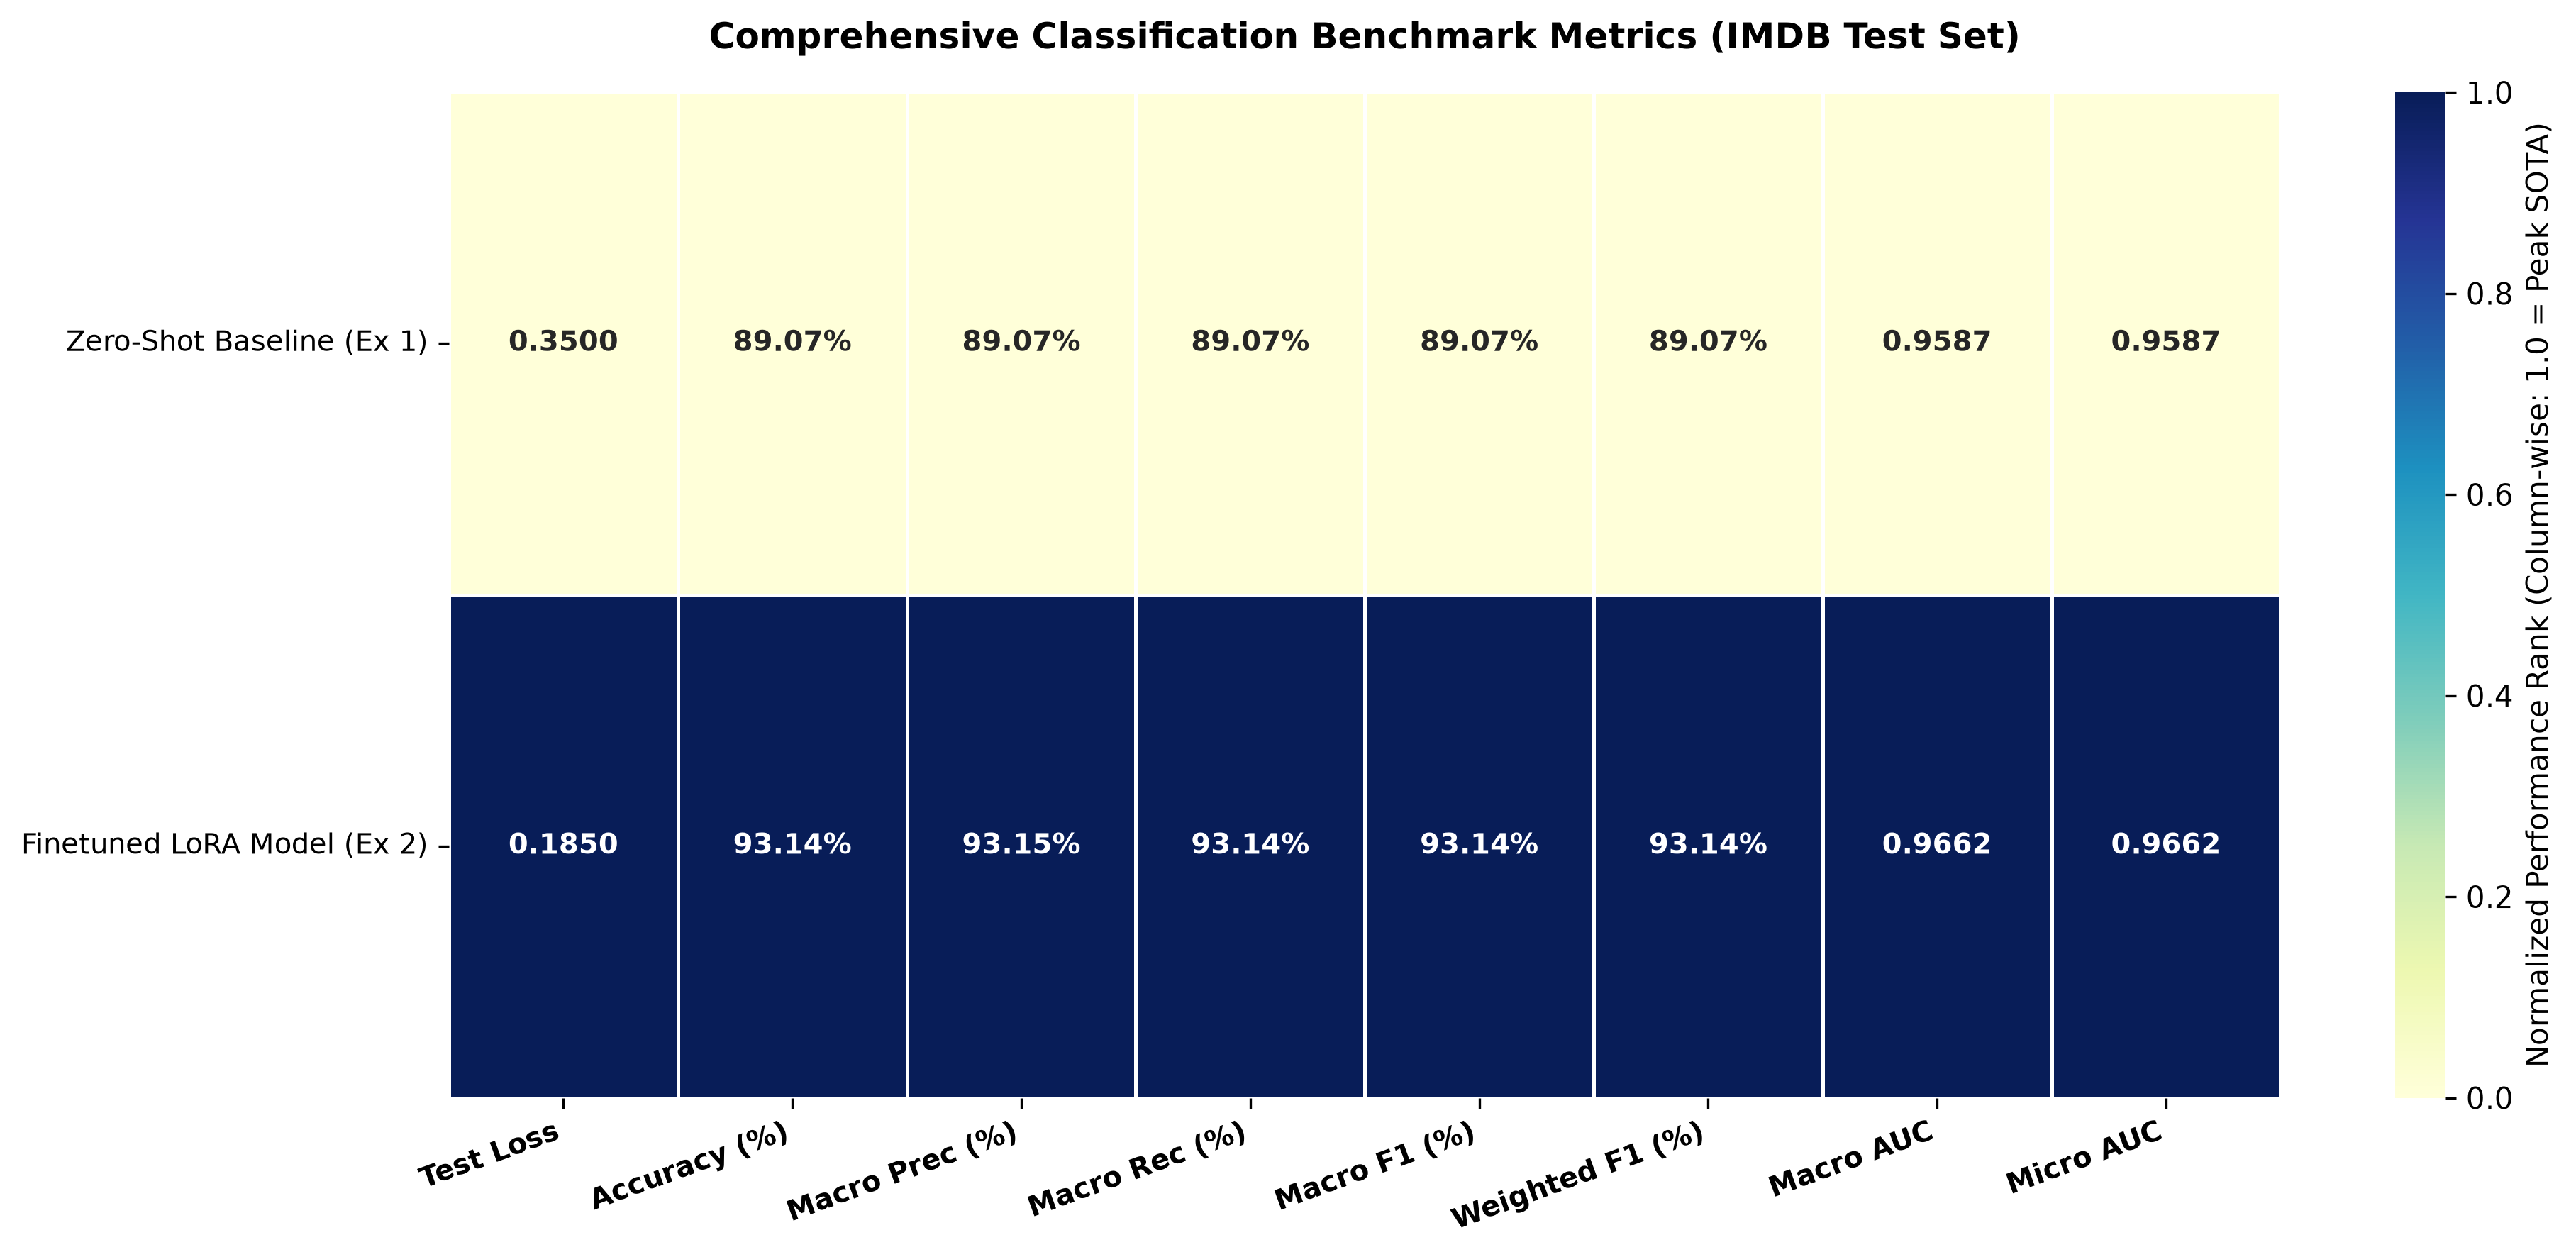

In [5]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 4: Interactive Baseline Execution & Test-Set Evaluation Suite
from src import IMDBTrainer, IMDBEvaluator, IMDBPlotter

# 1. Option to re-run Baseline Evaluation via IMDBTrainer
trainer = IMDBTrainer(preset_name="EXP-BASE", project_root=PROJECT_ROOT)
print("Executing Exercise 1 Baseline Pipeline...")
trainer.run_training()

# 2. Evaluate Zero-Shot Baseline Test Accuracy on Sealed 25,000 Reviews
evaluator = IMDBEvaluator(project_root=PROJECT_ROOT)
evaluator.evaluate_zero_shot_baseline()

# 3. Comprehensive Benchmark Metric Table & Seaborn Summary Heatmap
evaluator.render_comprehensive_benchmark()

# 4. Display Exercise 1 Baseline Artifacts (Benchmark Bars, Zero-Shot ROC Curve, Baseline Confusion Matrix & Heatmap)
plotter = IMDBPlotter(project_root=PROJECT_ROOT)
plotter.display_zero_shot_baseline_artifacts()
